# **Práctica 2.2**: Ataques adversarios y robustez en Visión Artificial con modelos de Deep Learning

# **Introducción**
Esta práctica tiene como objetivo evaluar la robustez de las Redes Neuronales Convolucionales (CNN) frente a ataques adversarios de "caja blanca" (*white-box*). En este escenario, el atacante tiene acceso total a los pesos y la arquitectura del modelo, permitiéndole calcular el gradiente de la función de pérdida respecto a la imagen de entrada.

Se utiliza el conjunto de datos **CIFAR-10** para entrenar un modelo base y, posteriormente, se implementa el ataque **Projected Gradient Descent (PGD)**. Este ataque se analiza bajo la norma $L_\infty$ para garantizar que las perturbaciones introducidas sean imperceptibles para el ojo humano, evaluando el equilibrio entre la precisión del modelo y su capacidad de generalización ante datos malintencionados.

---
### **Imports** necesarios y **fijado** **de** **semilla** para garantizar la reproducibilidad del notebook

In [1]:
import torch
import numpy as np
import random
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
import torch.nn as nn
import matplotlib.pyplot as plt
from tqdm import tqdm

!pip -q install adversarial-robustness-toolbox
from art.estimators.classification import PyTorchClassifier
from art.attacks.evasion import SaliencyMapMethod

def set_seed(seed=42):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(42)

if torch.cuda.is_available(): device = "cuda"
elif torch.backends.mps.is_available(): device = "mps"
else: device = "cpu"

print(f"El notebook se ejecutará en el dispositivo: [{device}]!")


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


/Users/alvaro/Desktop/IA/4º/2ºcuatrimestre/IA en Ciberseguridad/Practicas/Practica2/CNN-Adversarial-Attacks-Defense/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


El notebook se ejecutará en el dispositivo: [mps]!


### **Definición de funciones auxiliares**

In [2]:
def train_model(model, epochs, optim, criterion, train_dataloader, device):
    model.to(device)
    for epoch in range(epochs):
        model.train()
        train_loss = 0.0
        for imgs, labels in train_dataloader:
            imgs, labels = imgs.to(device), labels.to(device)

            optim.zero_grad()
            outputs = model(imgs)
            loss = criterion(outputs, labels)
            loss.backward()
            optim.step()

            train_loss += loss.item()
        
        print(f'Época {epoch+1}/{epochs} - Loss: {train_loss / len(train_dataloader):.4f}')
    
    return model

def eval_model(model, test_dataloader, device):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for imgs, labels in tqdm(test_dataloader, desc='Evaluando modelo'):
            imgs, labels = imgs.to(device), labels.to(device)
            outputs = model(imgs)
            predicted = torch.argmax(outputs, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    
    return correct / total

def visualize_predictions(model, loader, classes, device, attack_fn=None, attack_params=None):
    model.eval()
    images, labels = next(iter(loader))
    images, labels = images[:10].to(device), labels[:10].to(device)

    if attack_fn:
        images = attack_fn(model, images, labels, **attack_params)
    
    with torch.no_grad():
        outputs = model(images)
        preds = torch.argmax(outputs, 1)
    
    plt.figure(figsize=(20, 6))
    for i in range(10): 
        plt.subplot(2, 5, i+1)
        img = images[i].cpu().numpy().transpose((1, 2, 0))
        plt.imshow(np.clip(img, 0, 1))
        
        color = "green" if preds[i] == labels[i] else "red"
        plt.title(f"Pred: {classes[preds[i]]}\nReal: {classes[labels[i]]}", color=color, fontsize=10)
        plt.axis('off')
    
    plt.tight_layout()
    plt.show()

---
## **Parte 1 - Modelo base sobre CIFAR-10**

### **1.1 Descripción del dataset CIFAR-10**

El conjunto de datos `CIFAR-10` es un estándar en la comunidad de aprendizaje profundo para tareas de clasificación de imágenes. Consta de un total de 60,000 imágenes a color de baja resolución (32x32 píxeles), distribuidas uniformemente en 10 clases: `avión`, `coche`, `pájaro`, `gato`, `ciervo`, `perro`, `rana`, `caballo`, `barco` y `camión`.

Para esta práctica, utilizaremos la partición estándar de 50,000 imágenes para entrenamiento y 10,000 imágenes para test, lo que nos permitirá evaluar la capacidad de generalización del modelo antes de someterlo a perturbaciones adversarias.

### **1.2 Preprocesamiento**

A diferencia de los flujos de trabajo convencionales, hemos diseñado un preprocesamiento específico para facilitar la generación de ataques adversarios:
- **Conversión a Tensor**: Las imágenes se transforman a tensores de PyTorch, escalando sus valores al rango $[0, 1]$.
- **Normalización Interna**: No aplicaremos la normalización estadística (sustracción de la media y división por la desviación típica) en el `DataLoader`. En su lugar, esta operación se integrará directamente en la arquitectura de la red neuronal.
  - *Justificación*: Esto permite que el ataque adversario busque perturbaciones en el espacio físico real de la imagen, garantizando que el presupuesto $\epsilon$ sea directamente interpretable y evitando artefactos de "clipping" incorrectos.

In [3]:
transform = transforms.Compose([
    transforms.ToTensor()
])

train_dataset = torchvision.datasets.CIFAR10(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.CIFAR10(root='./data', train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=128, shuffle=False)

/Users/alvaro/Desktop/IA/4º/2ºcuatrimestre/IA en Ciberseguridad/Practicas/Practica2/CNN-Adversarial-Attacks-Defense/.venv/lib/python3.12/site-packages/torchvision/datasets/cifar.py:83: VisibleDeprecationWarning: dtype(): align should be passed as Python or NumPy boolean but got `align=0`. Did you mean to pass a tuple to create a subarray type? (Deprecated NumPy 2.4)
  entry = pickle.load(f, encoding="latin1")


### **1.3 Definición de la arquitectura CNN**

Se ha implementado una red neuronal convolucional (`SimpleCNN`) optimizada para `CIFAR-10`. La arquitectura incluye:

- **Extracción de características**: Dos bloques convolucionales con activación ReLU y capas de Max-Pooling para reducir la dimensionalidad espacial.

- **Clasificación**: Capas totalmente conectadas con Dropout para mitigar el sobreajuste.

- **Capa de Normalización Integrada**: Utilizando register_buffer, el modelo almacena los parámetros estadísticos de `CIFAR-10`. Esto asegura que el modelo sea capaz de procesar imágenes en el rango $[0, 1]$ normalizándolas "al vuelo" antes de las capas convolucionales.

In [13]:
class SimpleCNN(nn.Module):
    def __init__(self, mean, std):
        super().__init__()

        self.register_buffer('mean', torch.tensor(mean).view(1, 3, 1, 1))
        self.register_buffer('std', torch.tensor(std).view(1, 3, 1, 1))

        self.layer1 = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.layer2 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)
        )

        self.linear_layer = nn.Sequential(
            nn.Flatten(),
            nn.Linear(64 * 8 * 8, 512),
            nn.ReLU(),
            nn.Dropout(0.25),
            nn.Linear(512, 10)
        )
    
    def forward(self, x):
        x = (x - self.mean.to(device)) / self.std.to(device)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.linear_layer(x)
        return x

mean_cifar = [0.4914, 0.4822, 0.4465]
std_cifar = [0.2023, 0.1994, 0.2010]

# Instanciación correcta
model = SimpleCNN(mean_cifar, std_cifar).to(device)
print('[INFO] Red CNN con normalización interna definida!')

[INFO] Red CNN con normalización interna definida!


### **1.4 Entrenamiento del modelo**

El modelo se entrena utilizando el optimizador `AdamW`, elegido por su eficiente manejo de la regularización L2 (`weight decay`). Se emplea una tasa de aprendizaje de $1e-3$ y la función de pérdida de Entropía Cruzada (`CrossEntropyLoss`). El proceso se lleva a cabo durante 20 épocas, buscando un equilibrio entre la convergencia de la pérdida y la estabilidad del accuracy en el conjunto de validación.

In [5]:
criterion = nn.CrossEntropyLoss()
optim = torch.optim.AdamW(model.parameters(), lr=1e-3, weight_decay=1e-5)

model = train_model(model, 20, optim, criterion, train_loader, device)

Época 1/20 - Loss: 1.3503
Época 2/20 - Loss: 0.9508
Época 3/20 - Loss: 0.7848
Época 4/20 - Loss: 0.6571
Época 5/20 - Loss: 0.5434
Época 6/20 - Loss: 0.4416
Época 7/20 - Loss: 0.3467
Época 8/20 - Loss: 0.2764
Época 9/20 - Loss: 0.2197
Época 10/20 - Loss: 0.1811
Época 11/20 - Loss: 0.1459
Época 12/20 - Loss: 0.1268
Época 13/20 - Loss: 0.1187
Época 14/20 - Loss: 0.1023
Época 15/20 - Loss: 0.0953
Época 16/20 - Loss: 0.0924
Época 17/20 - Loss: 0.0825
Época 18/20 - Loss: 0.0802
Época 19/20 - Loss: 0.0770
Época 20/20 - Loss: 0.0731


### **1.5 Evalución inicial**
Una vez finalizado el entrenamiento, procedemos a realizar una evaluación inicial en el conjunto de test "limpio" (sin ataques). El objetivo es establecer un *baseline* que nos sirva para cuantificar la pérdida de precisión ante ejemplos adversarios. Además, visualizaremos una muestra de predicciones donde el color del título indicará si la clasificación ha sido correcta (verde) o errónea (rojo).

In [6]:
clean_acc = eval_model(model, test_loader, device)
print(f"Accuracy en el conjunto de test original: {clean_acc * 100:.2f}%")

Evaluando modelo: 100%|██████████| 79/79 [00:00<00:00, 144.64it/s]

Accuracy en el conjunto de test original: 73.06%


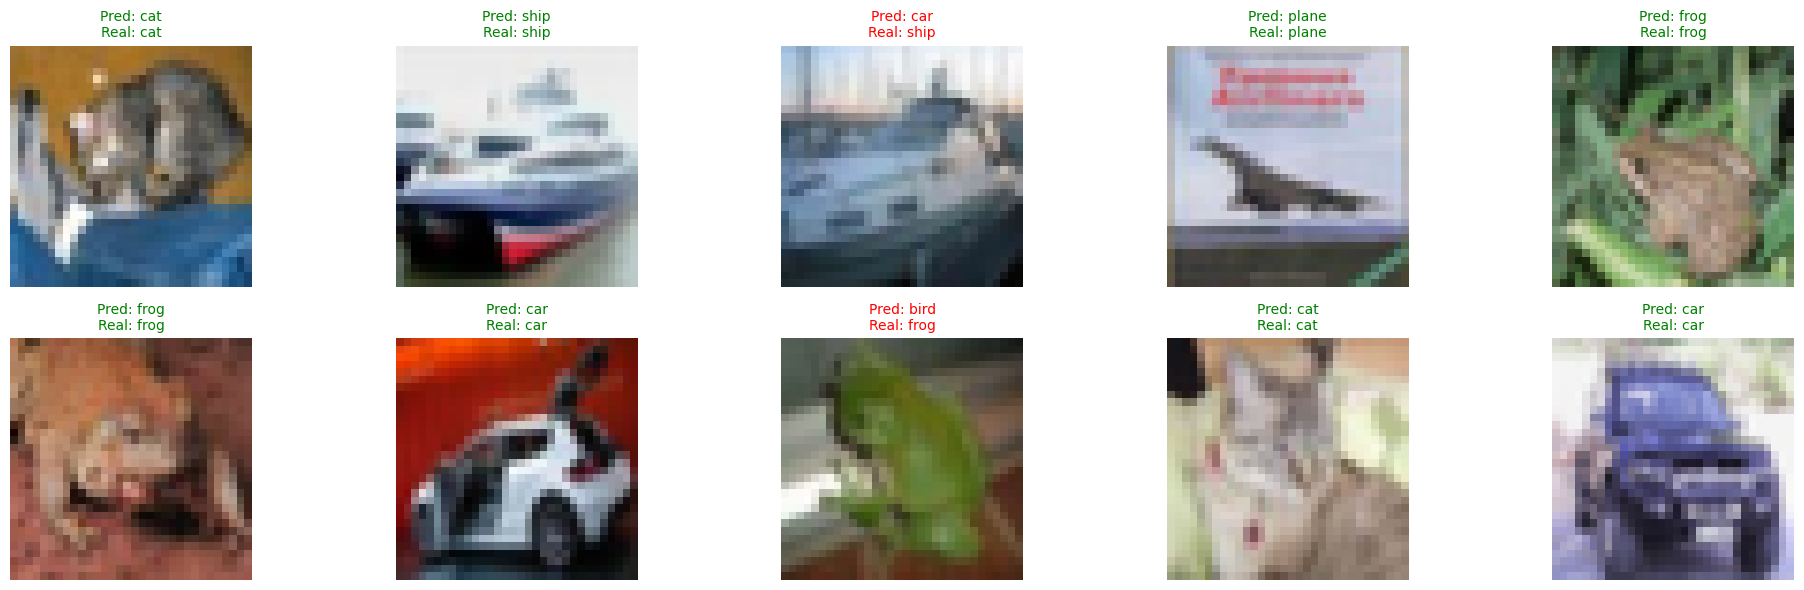

In [7]:
classes = ('plane', 'car', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck')
visualize_predictions(model, test_loader, classes, device)

---
## **Parte 2 - Ataques adversarios**

Es este apartado del cuaderno se desarrollará la lógica necesaria para generar ejemplos adversarios y evaluar la robustez de la red entrenada previamente.

Para ello, se implementarán funciones de soporte encargadas de calcular las métricas de éxito del ataque y de cuantificar la magnitud de las perturbaciones introducidas. El objetivo principal será definir un marco para la evaluación de la robustez del modelo frente a diferentes niveles de ataque *white-box*

In [8]:
def make_target_labels(y, num_classes=10, strategy="next"):
    y_np = np.array(y, dtype=np.int32).reshape(-1)
    if strategy == "next": tgt = (y_np + 1) % num_classes
    elif strategy == "farthest": tgt = (y_np + (num_classes // 2)) % num_classes
    else:
        try:
            c = int(strategy)
            tgt = np.full_like(y_np, c)
        except:
            raise ValueError("Estrategia de objetivos no soportada.")

    y_tgt = np.zeros((y_np.shape[0], num_classes), dtype=np.float32)
    y_tgt[np.arange(y_np.shape[0]), tgt] = 1.0
    return y_tgt, tgt

def compute_norms(delta, l0_thresh=1e-6):
    """
    Calcula las normas L0, L2 y Linf para un batch de perturbaciones en PyTorch.
    delta: torch.Tensor de forma (N, C, H, W)
    """
    delta_abs = torch.abs(delta)
    
    l_inf = torch.amax(delta_abs, dim=[1, 2, 3])
    l2 = torch.norm(delta.view(delta.shape[0], -1), p=2, dim=1)
    l0 = torch.sum((delta_abs > l0_thresh).float(), dim=[1, 2, 3])
    
    return l0, l2, l_inf


def evaluate_attack(model: SimpleCNN, data_loader: DataLoader, attack_fn: callable, attack_params: dict, device: torch.device, max_batches: int = None, targeted_attack: bool = False):
    """
    Función encargada de los resultados de un ataque de tipo white-box dado un modelo de clasificación.
    
    [PARÁMETROS]
        * model: SimpleCNN - Modelo sobre el cual vamos a realizar el ataque.
        * data_loader: DataLoader - Objeto encargado de cargar el conjunto de datos sobre el que se va a realizar el ataque.
        * attack_fn: callable - Ataque seleccionado para su evaluación.
        * attack_params: dict - Parámetros del ataque.
        * device: torch.device - Device donde se esta realizando la ejecución del cuaderno.
        * max_batches: int - Parametro opcional que sirve para limitar el numero de batches para la evalución del ataque. Este se añade con la finalidad de hacer más ligera la evaluación
        * targeted_attack: bool - Parámetro booleno que sirve para diferenciar la evaluación de un ataque guiado o no.
    
    [RETURN]
        * res: dict - Diccionario que recogerá las métricas básicas de evaluación de ataques white-box: 
        - clean_accuracy, 
        - robust_accuracy, 
        - ASR, 
        - TSR (solo si el ataque es dirigido)
        - L_0
        - L_2
        - L_inf
    """
    n_total = 0
    n_clean_correct = 0
    n_adv_correct = 0
    n_success_attack = 0
    if targeted_attack:
        n_target_success = 0

    l0_list, l2_list, linf_list = [], [], []

    model.eval()

    for b_idx, (x, y) in enumerate(tqdm(data_loader, desc="Evaluando ataque sobre conjunto de datos")):
        
        if (max_batches is not None) and (b_idx >= max_batches): break

        x, y = x.to(device), y.to(device)
        
        with torch.no_grad():
            out = model(x)
            pred_clean = torch.argmax(out, dim=1)


        x_adv = attack_fn(model, x, y, **attack_params)
        with torch.no_grad():
            out = model(x_adv)
            pred_adv = torch.argmax(out, dim=1)
        
        # Añadir logica de target label en caso de ataque guiado
        if targeted_attack:
            _, y_tgt = make_target_labels(y.cpu().numpy(), strategy=attack_params['target_strategy'])
            y_tgt = torch.from_numpy(y_tgt).to(device)

        n_batch = x.shape[0]
        n_total += n_batch

        clear_correct_mask = (y == pred_clean)
        adv_correct_mask = (y == pred_adv)
        adv_wrong_mask = (y != pred_adv)

        n_clean_correct += clear_correct_mask.sum().item()
        n_adv_correct += adv_correct_mask.sum().item()
        n_success_attack += (clear_correct_mask & adv_wrong_mask).sum().item()
        if targeted_attack:
            n_target_success += (pred_adv == y_tgt).sum().item()

        delta = x_adv - x
        l0, l2, linf = compute_norms(delta)
        l0_list.extend(l0.detach().cpu().numpy())
        l2_list.extend(l2.detach().cpu().numpy())
        linf_list.extend(linf.detach().cpu().numpy())
    
    clean_acc = n_clean_correct / n_total
    adv_acc = n_adv_correct / n_total
    ASR = n_success_attack / (n_clean_correct + 1e-9)

    res = {
        "clean_accuracy": clean_acc,
        "robust_accuracy": adv_acc,
        "ASR": ASR,
        "mean_L0": float(np.mean(l0_list)),
        "mean_L2": float(np.mean(l2_list)),
        "mean_Linf": float(np.mean(linf_list))
    }

    if targeted_attack:
        res['TSR'] = n_target_success / n_total

    return res


### **2.1 Projected Gradient Descent - PGD**

Como primer ataque adeversario, se ha decidido implementar **Projected Gradient Descent (PGD)** como eje central de la evaluación de robustez. Esta elección fundamentalmene es porque PGD es considerado como el **Estado del Arte** (SoTA) entre los ataques de primer orden basados en signo de gradiente.

La principal ventaja, y segunda razón de la selección de este ataque como primera implementación, es su modularidad, ya que PGD puede llegar a funcionar como una generalización de los otros ataques fundamentales basados en signo de gradiente. Esto se consigue al ajustar los parámetros de iteraciones (`steps`) y reinicios aleatorios (`restarts`), podemos emular y comparar tres ataques diferentes con una única base de código:

1. **FGSM (Fast Gradient Sign Method)**: Configurando `steps=1`, `restarts=1` y `alpha = epsilon`. Es el ataque más rápido y simple de un solo paso.
2. **BIM (Basic Iterative Method)**: Configurando `steps > 1` y `restarts=1`. Es la versión iterativa del anterior ataque (FSGM) sin aleatoriedad inicial.
3. **PGD (Projected Gradient Descend)**: Configurando `steps > 1` y `restarts > 1`. Añade reinicios aleatorios para evitar que el ataque se quede atrapado en un máximo local, siendo este el ataque más potente de los tres.

Esta estrategia permite realizar una comparativa exhaustiva de la robustez del modelo frente a diferentes niveles de agresividad de ataque.

In [9]:
def _pgd_core(model: SimpleCNN, x: torch.tensor, y: torch.tensor, steps: int, alpha, epsilon: float, clip_min:float = 0.0, clip_max: float = 1.0):
    
    x_adv = x.clone().detach()

    noise = torch.empty_like(x).uniform_(-epsilon, epsilon).to(x.device)
    x_adv = x_adv + noise
    x_adv = torch.clamp(x_adv, clip_min, clip_max)

    x_adv.requires_grad_(True)

    criterion = nn.CrossEntropyLoss()

    for _ in range(steps):

        out = model(x_adv)
        loss = criterion(out, y)
        loss.backward()

        with torch.no_grad():
            grad_sing = torch.sign(x_adv.grad)
            x_adv.data = x_adv.data + alpha * grad_sing
            x_adv.data = x.data + torch.clamp(x_adv.data - x.data, min=-epsilon, max=epsilon)
            x_adv.data = torch.clamp(x_adv.data, clip_min, clip_max)
        
        x_adv.grad.zero_()
          
    return x_adv.detach()


def pgd_attack(model: SimpleCNN, x: torch.tensor, y: torch.tensor, restarts: int, steps: int, alpha: float = None, epsilon: float = 0.1, min_clip: float = 0.0, max_clip: float = 1.0):
    """
    Implementación del ataque PGD con posibilidad de varios reinicios 
    """
    model.eval()
    if alpha is None:
        alpha = epsilon / steps
    
    criterion = nn.CrossEntropyLoss(reduction='none')

    if restarts <= 1:
        return _pgd_core(model, x, y, steps, alpha, epsilon, min_clip, max_clip)
    
    best_x_adv = x.clone().detach()
    best_loss = torch.full((x.shape[0],), -1e9, device=x.device)
    for _ in range(restarts):
        x_adv_candidate = _pgd_core(model, x, y, steps, alpha, epsilon, min_clip, max_clip)
        with torch.no_grad():
            out = model(x_adv_candidate)
            current_loss = criterion(out, y)
        
            better = current_loss > best_loss
            best_loss[better] = current_loss[better]

            best_x_adv[better] = x_adv_candidate[better]

    return best_x_adv

### **2.2 Jacobian-based Saliency Map Attack (JSMA)**

Tras la elección un ataque white-box de primer order como primera opción, como segundo ataque se decide implementar el **Jacobian-based Saliency Map Attack (JSMA)** para analizar la vulnerabilidad del modelo desde una perspectiva de clases de equivalencia y prominencia de características. A diferencia de los ataques anteriores basados en la norma $L_\infty$, JSMA se centra en la optimización de la norma $L_0$, buscando minimizar el número de píxeles modificados mientras se maximiza el impacto en la clasificación.

La elección de JSMA responde a dos objetivos estratégicos:

- **Ataque Quirúrgico**: Evaluar si el modelo puede ser engañado alterando apenas una fracción mínima de la imagen (píxeles críticos), lo que contrasta con el ruido distribuido del PGD
- **Naturaleza Dirigida (Targeted)**: A diferencia de las pruebas anteriores, JSMA utiliza la matriz Jacobiana para forzar al modelo a predecir una clase objetivo específica (Targeted Success Rate), permitiendo medir no solo la fragilidad del modelo, sino también su manipulabilidad hacia resultados predeterminados por el atacante.

In [ ]:
_ART_CLASSIFIER = None
def get_art_classifier(model, criterion, optimizer):
    global _ART_CLASSIFIER
    if _ART_CLASSIFIER is None:
        _ART_CLASSIFIER = PyTorchClassifier(
            model=model,
            clip_values=(0.0, 1.0),
            loss=criterion,
            optimizer=optimizer,
            input_shape=(3, 32, 32), # Tamaño datos CIFAR-10 
            nb_classes=10,
            device_type=device
        )
    return _ART_CLASSIFIER

def jsma_attack(model: staticmethod, x: torch.tensor, y: torch.tensor, criterion: nn.Module, optimizer: torch.optim.Optimizer, gamma: float, theta: float, target_strategy: (str|int) ="next"):
    
    classifier = get_art_classifier(model, criterion, optimizer)

    x_np = x.cpu().detach().numpy()
    y_np = y.cpu().detach().numpy()

    y_target_onehot, _ = make_target_labels(y_np, num_classes=10, strategy=target_strategy)

    attack = SaliencyMapMethod(
        classifier=classifier,
        theta=theta,
        gamma=gamma,
        batch_size=x_np.shape[0],
        verbose=False
    )

    x_adv_np = attack.generate(x=x_np, y=y_target_onehot)
    x_adv = torch.from_numpy(x_adv_np).to(device)

    return x_adv

---
## **Parte 3 - Evaluación de robustez**

In [ ]:
attacks = {
    'FSGM': {'restarts': 1, 'steps': 1, 'alpha': 0.01, 'epsilon': 0.01},
    'BIM': {'restarts': 1, 'steps': 10, 'epsilon': 0.01},
    'PGD': {'restarts': 5, 'steps': 10, 'epsilon': 0.01}
}

print(evaluate_attack(model, test_loader, pgd_attack, attacks['PGD'], device))
visualize_predictions(model, test_loader, classes, device, pgd_attack, attacks['PGD'])

In [ ]:
jsma_params = {
    'optimizer': optim, 
    'criterion': criterion, 
    'gamma': 0.1,
    'theta': 1.0,
    'target_strategy': 'next'
}
print(evaluate_attack(model, test_loader, jsma_attack, jsma_params, device, None , True))
visualize_predictions(model, test_loader, classes, device, jsma_attack, jsma_params)

Para luego la parte de probar el ataque según diferentes parámetros, será interesante sobre todo probar los diferentes valores de $\epsilon$, viendo tanto como afecta al rendimiento del modelo como a como afecta a la perceptibilidad de las imágenes modificadas.

Se ha modificado el flujo de datos para realizar la normalización estadística dentro de la propia arquitectura del modelo. Esto permite que el espacio de búsqueda del ataque adversario coincida con el espacio físico de la imagen $$, garantizando la interpretabilidad de las métricas de perturbación $L$ y evitando artefactos durante el proceso de clipping.

---
## **Parte 4 - Vulnerabilidades y defensas**

## Vulnerabilidades:

En relacion a ataques iterativos sobre norma $L_\infty$ como BIM y el siguietne:

Relación con tu prácticaEn tu análisis de Vulnerabilidades y Defensas (Parte 4), puedes mencionar que:"El éxito del ataque no depende solo del número de pasos, sino de si el presupuesto $\epsilon$ es suficiente para alcanzar la frontera de decisión del modelo antes de que los píxeles se saturen en los límites de la bola $L_\infty$ o en los rangos de color $[1][cite_start]$." Esto demuestra que entiendes por qué, a veces, aumentar los steps de 10 a 100 no mejora el ASR (Attack Success Rate) si el $\epsilon$ es demasiado pequeño.

Comentar tambien que la búsqueda de este valor de $\epsilon$ para nuestro modelo, a veces, también puede llegar a servir para engañar otros modelos (Transferibilidad).